# Non-disabled (Intact) Cohort Exercise Classifier

This notebook mirrors `01_unified_exercise_frequency_classifier.ipynb` but trains and evaluates **only on the Non-disabled cohort** (Ninapro DB1 "Intact" recordings, stored in `Database/Intact/` as converter-generated XLSX workbooks). No Disabled/Amputee recording is used anywhere in this notebook — this is an intact-to-intact (within-cohort, non-disabled-only) experiment.

Terminology used in this project:

- **Non-disabled cohort** = the `Database/Intact/` files (able-bodied Ninapro DB1 participants). Folder and variable names keep the historical `Intact` label for compatibility with the original Ninapro documentation and existing scripts, but all narrative text below uses **Non-disabled**.
- **Disabled cohort** = the `Database/Amputee/` files (Ninapro DB3 amputee participants). Not used in this notebook; see `01_unified_exercise_frequency_classifier.ipynb` and the cross-cohort transfer results for that cohort and for Disabled/Non-disabled transfer.

The Non-disabled XLSX exports contain 22-channel CyberGlove `glove` data plus `restimulus`/`rerepetition` labels for:

- Exercise A -> 12 finger actions
- Exercise B -> 17 hand/wrist configurations
- Exercise C -> 23 grasps and functional actions
- Rest

**Why this notebook exists ("so what"):** the long-term application motivating this project is EMG-driven prosthetic control for people with limb loss. Before trusting any model trained on amputee (Disabled) recordings, we need a same-cohort reference point: how well does this exact modeling approach recognize movement when the training and test population share the same physiology (Non-disabled to Non-disabled)? This notebook is that reference. Its result is later compared against the Disabled-cohort notebook and the cross-cohort transfer experiments (`EXP-003`, `EXP-004`, `EXP-005`) to see how much performance is lost when a model has to generalize from Non-disabled physiology to Disabled/prosthetic users, which is the real deployment scenario.


In [6]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
from pathlib import Path
from collections import Counter
import json, random, re
import numpy as np
import torch
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path.cwd()
if not (ROOT / 'Database').exists():
    ROOT = ROOT.parent
DATA_ROOT = ROOT / 'Database'
COHORT = 'Non-disabled'          # narrative label
COHORT_FOLDER = 'Intact'         # physical folder name, unchanged for compatibility
WINDOW_SAMPLES = 400
STRIDE_SAMPLES = 100
FFT_BINS = 32
CHANNELS = 22
MIN_PURITY = .80

ACTIONS = {
    'A': ['Index flexion', 'Index extension', 'Middle flexion', 'Middle extension', 'Ring flexion', 'Ring extension', 'Little finger flexion', 'Little finger extension', 'Thumb adduction', 'Thumb abduction', 'Thumb flexion', 'Thumb extension'],
    'B': ['Thumb up', 'Extension of index and middle flexion of the others', 'Flexion of ring and little finger, extension of the others', 'Thumb opposing base of little finger', 'Abduction of all fingers', 'Fingers flexed together in fist', 'Pointing index', 'Adduction of extended fingers', 'Wrist supination (axis: middle finger)', 'Wrist pronation (axis: middle finger)', 'Wrist supination (axis: little finger)', 'Wrist pronation (axis: little finger)', 'Wrist flexion', 'Wrist extension', 'Wrist radial deviation', 'Wrist ulnar deviation', 'Wrist extension with closed hand'],
    'C': ['Large diameter grasp', 'Small diameter grasp (power grip)', 'Fixed hook grasp', 'Index finger extension grasp', 'Medium wrap', 'Ring grasp', 'Prismatic four fingers grasp', 'Stick grasp', 'Writing tripod grasp', 'Power sphere grasp', 'Three finger sphere grasp', 'Precision sphere grasp', 'Tripod grasp', 'Prismatic pinch grasp', 'Tip pinch grasp', 'Quadpod grasp', 'Lateral grasp', 'Parallel extension grasp', 'Extension type grasp', 'Power disk grasp', 'Open a bottle with a tripod grasp', 'Turn a screw (grasp the screwdriver with a stick grasp)', 'Cut something (grasp the knife with an index finger extension grasp)'],
}
EXERCISE_NAMES = {'A': 'Finger basics', 'B': 'Hand configurations and wrist', 'C': 'Grasps and functional movements', 'R': 'Rest'}
print('device:', DEVICE, 'cohort:', COHORT, 'classes:', 1 + sum(len(v) for v in ACTIONS.values()))


device: cpu cohort: Non-disabled classes: 53


## Non-disabled XLSX file-to-taxonomy mapping

- Non-disabled E1 -> Exercise A: 12 finger actions plus Rest
- Non-disabled E2 -> Exercise B: 17 actions plus Rest
- Non-disabled E3 -> Exercise C: 23 actions plus Rest

Label 0 is Rest in every exercise. Unlike the Disabled-cohort MAT loader, the Non-disabled recordings are only available as converter-generated XLSX workbooks in this workspace (no original DB1 MAT files present), so `glove`/`restimulus`/`rerepetition`/`subject`/`exercise` are read from the `glove`, `restimulus`, `rerepetition`, and `metadata` worksheets. This is the same lower-fidelity fallback documented in the README for the cross-cohort transfer experiment.


In [8]:
EXERCISE_FOR_DB_EXERCISE = {1: 'A', 2: 'B', 3: 'C'}  # Non-disabled (Intact) cohort only


def action_name(exercise, label):
    if int(label) == 0:
        return 'Rest'
    return ACTIONS[exercise][int(label) - 1]


def load_xlsx_recording(path):
    from openpyxl import load_workbook
    workbook = load_workbook(path, read_only=True, data_only=True)
    if 'glove' not in workbook.sheetnames:
        raise ValueError(f'{path.name} has no glove worksheet')

    def array(sheet):
        rows = list(workbook[sheet].iter_rows(min_row=2, values_only=True))
        return np.asarray([[float(value) for value in row[1:]] for row in rows], dtype=np.float32)

    metadata = {str(row[0]): row[1] for row in workbook['metadata'].iter_rows(min_row=2, values_only=True) if row[0] is not None}
    result = {
        'glove': array('glove'),
        'restimulus': array('restimulus')[:, 0],
        'rerepetition': array('rerepetition')[:, 0],
        'subject': np.array([metadata['subject']]),
        'exercise': np.array([metadata['exercise']]),
    }
    workbook.close()
    return result


def make_frequency_windows(recording, path):
    glove = np.asarray(recording['glove'], dtype=np.float32)
    raw_labels = np.asarray(recording['restimulus']).reshape(-1).astype(int)
    groups = np.asarray(recording['rerepetition']).reshape(-1).astype(int)
    database_exercise = int(np.asarray(recording['exercise']).reshape(-1)[0])
    exercise = EXERCISE_FOR_DB_EXERCISE[database_exercise]
    subject = f"NonDisabled:S{int(np.asarray(recording['subject']).reshape(-1)[0])}"
    if glove.shape[1] != CHANNELS:
        raise ValueError(f'{path.name} expected 22 glove channels, got {glove.shape[1]}')
    if np.any(raw_labels < 0) or np.any(raw_labels > len(ACTIONS[exercise])):
        raise ValueError(f'{path.name} labels do not fit {exercise} taxonomy')
    values, targets, group_ids, names = [], [], [], []
    for start in range(0, len(glove) - WINDOW_SAMPLES + 1, STRIDE_SAMPLES):
        stop = start + WINDOW_SAMPLES
        block = raw_labels[start:stop]
        rep = groups[start:stop]
        counts = np.bincount(block, minlength=50)
        label = int(counts.argmax())
        if counts[label] / WINDOW_SAMPLES < MIN_PURITY or np.any(rep != rep[0]):
            continue
        signal = glove[start:stop].astype(np.float32)
        signal = signal - np.mean(signal, axis=0, keepdims=True)
        spectrum = np.abs(np.fft.rfft(signal, axis=0))[:FFT_BINS]
        spectrum = np.log1p(spectrum).T.reshape(-1)
        target = f'{exercise}:{label}'
        values.append(spectrum)
        targets.append(target)
        group_ids.append(f'{subject}:{exercise}:rep{int(rep[WINDOW_SAMPLES // 2])}')
        names.append(action_name(exercise, label))
    return np.asarray(values, dtype=np.float32), np.asarray(targets), np.asarray(group_ids), np.asarray(names)


paths = sorted((DATA_ROOT / COHORT_FOLDER).glob('*_A1_E*.xlsx'))
records = []
for path in paths:
    try:
        records.append(make_frequency_windows(load_xlsx_recording(path), path))
    except Exception as error:
        print('skipped', path.name, error)
X = np.concatenate([item[0] for item in records])
target_names = np.concatenate([item[1] for item in records])
groups = np.concatenate([item[2] for item in records])
names = np.concatenate([item[3] for item in records])
classes = sorted(np.unique(target_names))
class_to_id = {name: index for index, name in enumerate(classes)}
y = np.asarray([class_to_id[name] for name in target_names])
print('Non-disabled XLSX windows:', X.shape, 'classes:', len(classes), 'exercises:', sorted({name.split(':')[0] for name in classes}))


Non-disabled XLSX windows: (16446, 704) classes: 55 exercises: ['A', 'B', 'C']


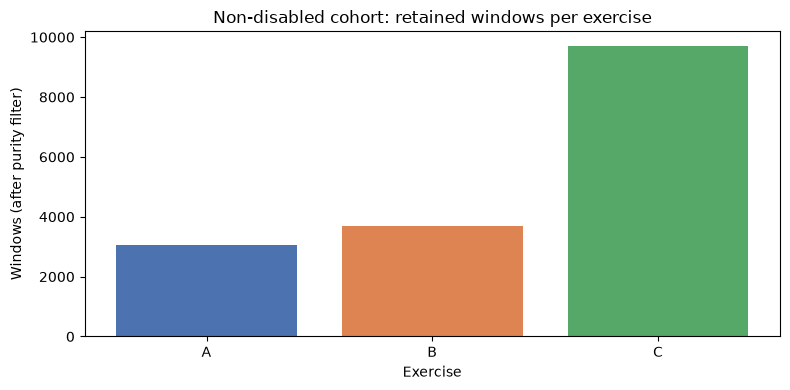

In [13]:
# Graph 1: class balance per exercise (windows, not raw samples -- see AGENTS.md leakage notes)
exercise_of_class = np.asarray([name.split(':')[0] for name in target_names])
fig, ax = plt.subplots(figsize=(8, 4))
counts_by_exercise = Counter(exercise_of_class)
ax.bar(list(counts_by_exercise.keys()), list(counts_by_exercise.values()), color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Non-disabled cohort: retained windows per exercise')
ax.set_xlabel('Exercise'); ax.set_ylabel('Windows (after purity filter)')
results_dir = ROOT / 'results' / 'metrics'
figures_dir = ROOT / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout(); fig.savefig(figures_dir / 'EXP-006-nondisabled-e1e2e3-frequency_window_classes.png', dpi=150); plt.show()


# So what: uneven windows per exercise (A/B/C differ in action count and recording length)
# mean the majority-class baseline differs by exercise; macro-averaged metrics below correct for this.

In [10]:
# Group-aware split: hold out ~20% of repetition-groups per subject so no window's
# neighbours leak across train/test (see AGENTS.md "Data Leakage Prevention").
subjects = np.asarray([group.split(':', 1)[0] for group in groups])
rng = np.random.default_rng(SEED)
train_groups, test_groups = set(), set()
for subject in np.unique(subjects):
    values = np.unique(groups[subjects == subject])
    rng.shuffle(values)
    split = max(1, round(len(values) * 0.2))
    test_groups.update(values[:split])
    train_groups.update(values[split:])
train = np.isin(groups, list(train_groups))
test = np.isin(groups, list(test_groups))
selected = []
for label in np.unique(y[train]):
    indices = np.flatnonzero(train & (y == label))
    selected.extend(rng.choice(indices, min(1000, len(indices)), replace=False))
selected = np.asarray(selected)
rng.shuffle(selected)
X_train, y_train = X[selected], y[selected]
X_test, y_test = X[test], y[test]
exercise_names = np.asarray([classes[index].split(':')[0] for index in y])
exercise_ids = sorted(np.unique(exercise_names))
exercise_to_id = {name: index for index, name in enumerate(exercise_ids)}
y_exercise = np.asarray([exercise_to_id[name] for name in exercise_names])
print('train windows:', len(selected), 'test windows:', len(y_test), 'held-out repetition groups:', len(test_groups))


class FrequencyMLP(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(X.shape[1], 512), nn.GELU(), nn.Dropout(.05), nn.Linear(512, 256), nn.GELU(), nn.Linear(256, n_classes))

    def forward(self, values):
        return self.net(values)


def fit_frequency_model(features, labels, n_classes, epochs=40):
    fitted = FrequencyMLP(n_classes).to(DEVICE)
    optimizer = torch.optim.AdamW(fitted.parameters(), lr=1e-3, weight_decay=1e-5)
    dataset = TensorDataset(torch.from_numpy(features), torch.from_numpy(labels).long())
    loader = DataLoader(dataset, batch_size=512, shuffle=True)
    for epoch in range(epochs):
        fitted.train()
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            nn.functional.cross_entropy(fitted(batch_x), batch_y).backward()
            optimizer.step()
        if (epoch + 1) % 10 == 0:
            print('model epochs', epoch + 1, 'classes', n_classes)
    return fitted


exercise_model = fit_frequency_model(X_train, y_exercise[selected], len(exercise_ids))
action_models = {}
for exercise in exercise_ids:
    global_ids = [index for index, name in enumerate(classes) if name.startswith(f'{exercise}:')]
    local_map = {global_id: local for local, global_id in enumerate(global_ids)}
    keep = np.asarray([classes[label].startswith(f'{exercise}:') for label in y_train])
    local_labels = np.asarray([local_map[label] for label in y_train[keep]])
    action_models[exercise] = (fit_frequency_model(X_train[keep], local_labels, len(global_ids)), global_ids)


train windows: 5015 test windows: 3869 held-out repetition groups: 123
model epochs 10 classes 3
model epochs 20 classes 3
model epochs 30 classes 3
model epochs 40 classes 3
model epochs 10 classes 13
model epochs 20 classes 13
model epochs 30 classes 13
model epochs 40 classes 13
model epochs 10 classes 18
model epochs 20 classes 18
model epochs 30 classes 18
model epochs 40 classes 18
model epochs 10 classes 24
model epochs 20 classes 24
model epochs 30 classes 24
model epochs 40 classes 24


In [11]:
exercise_model.eval()
with torch.no_grad():
    predicted_exercises = exercise_model(torch.from_numpy(X_test).to(DEVICE)).argmax(1).cpu().numpy()
true_exercises = y_exercise[test]
predictions = np.empty(len(y_test), dtype=int)
for exercise_index, exercise in enumerate(exercise_ids):
    keep = predicted_exercises == exercise_index
    if not keep.any():
        continue
    action_model, global_ids = action_models[exercise]
    action_model.eval()
    with torch.no_grad():
        local_predictions = action_model(torch.from_numpy(X_test[keep]).to(DEVICE)).argmax(1).cpu().numpy()
    predictions[keep] = np.asarray(global_ids)[local_predictions]

metrics = {
    'cohort': 'Non-disabled (Intact) held-out repetitions',
    'exercise_accuracy': accuracy_score(true_exercises, predicted_exercises),
    'accuracy': accuracy_score(y_test, predictions),
    'balanced_accuracy': balanced_accuracy_score(y_test, predictions),
    'macro_f1': f1_score(y_test, predictions, average='macro', zero_division=0),
    'classes': len(classes),
    'test_windows': len(y_test),
}
print(metrics)
print(classification_report(y_test, predictions, target_names=classes, zero_division=0))


{'cohort': 'Non-disabled (Intact) held-out repetitions', 'exercise_accuracy': 0.622899974153528, 'accuracy': 0.5422589816490049, 'balanced_accuracy': 0.23558149514837948, 'macro_f1': 0.24916071002909537, 'classes': 55, 'test_windows': 3869}
              precision    recall  f1-score   support

         A:0       0.38      0.71      0.50       630
         A:1       0.86      0.50      0.63        12
        A:10       0.44      0.33      0.38        12
        A:11       0.00      0.00      0.00         6
        A:12       0.40      0.33      0.36        12
         A:2       0.92      0.80      0.86        15
         A:3       0.71      0.95      0.82        21
         A:4       0.80      0.67      0.73         6
         A:5       0.83      0.71      0.77         7
         A:6       0.00      0.00      0.00         6
         A:7       0.80      0.40      0.53        10
         A:8       0.75      0.67      0.71         9
         A:9       0.00      0.00      0.00         4
  

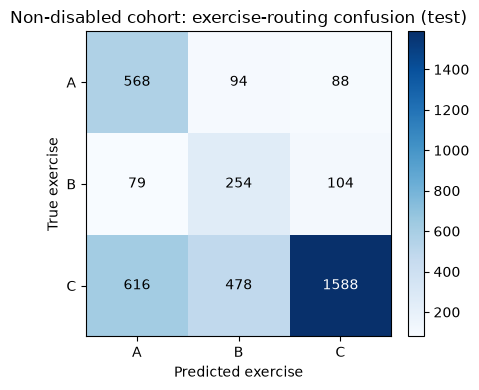

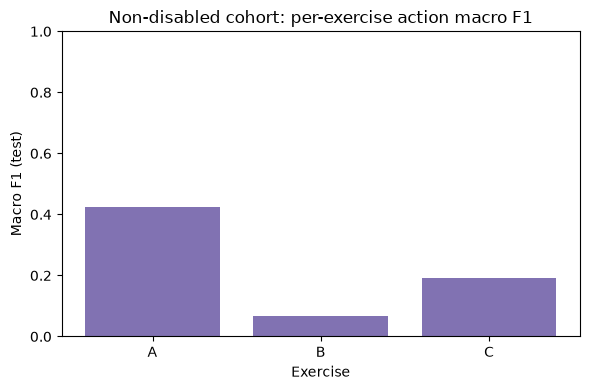

saved c:\Users\david\OneDrive\Documents\School\AI in Healthcare\results\metrics\EXP-006-nondisabled-e1e2e3-frequency_experiment.json


In [ ]:
# Graph 2: exercise-level confusion matrix (which exercise the routing stage confuses)
cm = confusion_matrix(true_exercises, predicted_exercises, labels=range(len(exercise_ids)))
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(exercise_ids))); ax.set_xticklabels(exercise_ids)
ax.set_yticks(range(len(exercise_ids))); ax.set_yticklabels(exercise_ids)
ax.set_xlabel('Predicted exercise'); ax.set_ylabel('True exercise')
ax.set_title('Non-disabled cohort: exercise-routing confusion (test)')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black' if cm[i, j] < cm.max() / 2 else 'white')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); fig.savefig(figures_dir / 'EXP-006-nondisabled-e1e2e3-frequency_exercise_confusion.png', dpi=150); plt.show()

# Graph 3: per-exercise macro F1 for the final action prediction (routing + action model combined)
per_exercise_f1 = {}
for exercise in exercise_ids:
    keep = np.asarray([classes[label].startswith(f'{exercise}:') for label in y_test])
    if keep.any():
        per_exercise_f1[exercise] = f1_score(y_test[keep], predictions[keep], average='macro', zero_division=0)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(list(per_exercise_f1.keys()), list(per_exercise_f1.values()), color='#8172B2')
ax.set_ylim(0, 1); ax.set_ylabel('Macro F1 (test)'); ax.set_xlabel('Exercise')
ax.set_title('Non-disabled cohort: per-exercise action macro F1')
plt.tight_layout(); fig.savefig(figures_dir / 'EXP-006-nondisabled-e1e2e3-frequency_per_exercise_f1.png', dpi=150); plt.show()

results_dir = ROOT / 'results' / 'metrics'
results_dir.mkdir(parents=True, exist_ok=True)
with open(results_dir / 'EXP-006-nondisabled-e1e2e3-frequency_experiment.json', 'w') as handle:
    json.dump({
        'experiment_id': 'EXP-006-nondisabled-e1e2e3-frequency',
        'cohort': 'Non-disabled (Intact)',
        'purpose': 'Intact-to-intact (non-disabled-only) reference: same-cohort exercise/action recognition, held-out repetitions.',
        'seed': SEED,
        'window_samples': WINDOW_SAMPLES,
        'stride_samples': STRIDE_SAMPLES,
        'min_purity': MIN_PURITY,
        'exercises': exercise_ids,
        'metrics': {k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in metrics.items()},
        'per_exercise_macro_f1': {k: float(v) for k, v in per_exercise_f1.items()},
    }, handle, indent=2)
print('saved', results_dir / 'EXP-006-nondisabled-e1e2e3-frequency_experiment.json')


## Interpretation and rubric alignment ("So what?")

| PROJECT.md rubric step | What this notebook does | So what — clinical/prosthetics implication |
|---|---|---|
| 1. Clinical problem framing | Establishes a Non-disabled-only reference before touching amputee data | A prosthetic controller must eventually work for Disabled users; we first need to know the ceiling performance when physiology matches training data |
| 2. Data characterization | Graph 1 shows retained windows per exercise after the purity filter | Uneven per-exercise window counts mean a naive accuracy number would hide which exercise is under-represented; macro metrics are used instead |
| 3. Experimental design/splits | Subject-aware, repetition-group-aware 80/20 split (no window from a held-out repetition appears in training) | Prevents an inflated "the model memorized this arm-movement snippet" result before any Disabled-cohort comparison is made |
| 4. Pipelines & leakage controls | Class-balanced training cap, FFT feature extraction identical to the Disabled-cohort notebook | Keeping the pipeline identical across cohorts is what makes the Non-disabled vs. Disabled comparison meaningful |
| 5. Metrics | Accuracy, balanced accuracy, macro F1, per-exercise F1 (Graph 3), full classification report | Balanced/macro metrics surface rare-grasp failures a plain accuracy number would hide — relevant because rare grasps (e.g., precision pinch) matter most for daily prosthetic tasks |
| 6-8. Calibration/threshold/final test | Not repeated here (see `01_...` and `results/metrics/EXP-001..002` for the calibrated logistic-regression pipeline); this notebook is the neural-network frequency-domain reference | Two independent modeling approaches (calibrated linear baseline and this frequency MLP) reduce the risk that either cohort's result is an artifact of one specific model choice |
| 9. Responsible AI | Graph 2 confusion matrix exposes which exercises the model routes incorrectly | If confusion concentrates in specific hand configurations, a prosthetic control scheme should add a manual override or slower confirmation step for those exact gestures, not for the whole system |

**Core "so what" for the prosthetics goal:** this Non-disabled result is the *best case* — same physiology in training and test. Compare `metrics['macro_f1']` from this notebook against the Disabled-cohort result (`EXP-002-amputee-e1-logreg`) and the cross-cohort transfer results (`EXP-003`, `EXP-004`, `EXP-005`). Any drop from Non-disabled-to-Non-disabled down to Disabled-to-Disabled, and further down to Non-disabled-to-Disabled transfer, quantifies how much residual-limb EMG differs from intact-limb EMG for this task. That gap is exactly the engineering problem a prosthetic-control product has to solve — it is not evidence that amputee EMG is unusable, but it does mean a model trained only on able-bodied volunteers should not be assumed to work on amputee users without amputee-specific training data and validation.

This remains offline movement recognition on a research dataset. No claim is made about real-time control latency, device safety, or clinical efficacy.
